### Exercise 2: Data Aqcuisition, Exploration, and Preprocessing

The task data can be found [here](https://github.com/CRLala/NLPLabs-2024/tree/main/Dont_Patronize_Me_Trainingset). More specifically, you will be using the [dontpatronizeme_pcl.tsv](https://github.com/CRLala/NLPLabs-2024/blob/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv) file. An allocation of this data into train and the official dev set is provided [here](https://github.com/Perez-AlmendrosC/dontpatronizeme/tree/master/semeval-2022/practice%20splits). The official test set (without the labels) can be found [here](https://github.com/Perez-AlmendrosC/dontpatronizeme/blob/master/semeval-2022/TEST/task4_test.tsv). The test-set labels are held out and will not be shared with you.

We will use it to evaluate your submitted model’s performance after the coursework submission deadline.
Note: the task repository also contains a breakdown of the type of PCL language detected for each example (broken down into seven categories). You are welcome to use this additional label information if it is helpful but don't forget the task you are working on is task 4 (subtask 1) which is Binary Classification (PCL vs No PCL).

Stage 2 is mainly about exploring the data. It involves a deep dive into the dataset to identify linguistic patterns, class imbalances, and noise. If you identify noise that can be cleaned easily, you ensure higher quality inputs for your binary classifiers and a more reliable training process downstream.

**Exploratory Data Analysis (EDA) [6 Marks | up to 3 Hours]**

Analyse the PCL dataset using two distinct EDA techniques (3 marks each).
For each technique, you must provide:
- Visual/Tabular Evidence: A figure or table.
- Analysis: A brief description of the findings.
- Impact Statement: An explanation of how this specific insight influences your approach to the PCL classification task

### Appendix: Exploratory Data Analysis

In NLP, Exploratory Data Analysis (EDA) focuses on the linguistic properties, patterns, and potential biases hidden in the text. Here is a breakdown of the typical NLP EDA workflow:

1. Basic Statistical Profiling
Before looking at the words, you look at the structure. This helps you determine your model's constraints (like maximum sequence length).
- Token Count: What is the average, minimum, and maximum sentence length?
- Vocabulary Size: How many unique words exist? This dictates the size of your embedding layer.
- Class Distribution: Is the dataset balanced? (e.g., In a hate speech task, if 98% of the data is "Non-Toxic," your model might achieve 98% accuracy just by guessing "Non-Toxic" every time).

2. Lexical Analysis (The "Word" Level)
This involves digging into the actual language used in the dataset.
- N-gram Analysis: What are the most common pairs (bigrams) or triplets (trigrams) of words? This reveals common phrases or domain-specific jargon.
- Stop Word Density: How much of the text is "filler" (the, is, at)? High density might mean you need more aggressive cleaning.
- Word Clouds & Frequency: A quick visual check to see if the most frequent words actually align with the task.

3. Semantic & Syntactic Exploration
Modern NLP requires understanding the "meaning" behind the statistics.
- Part-of-Speech (POS) Tagging: Are there more verbs than nouns? (e.g., in instruction-following tasks, verbs are dominant).
- Named Entity Recognition (NER): Does the dataset focus on specific people, locations, or organizations?
- Embedding Visualization: Using techniques like t-SNE or UMAP to project high-dimensional word vectors into 2D space. This allows you to see if similar concepts are naturally clustering together before you even train a model.

4. Identifying "Noise" and Artifacts
The most important part of EDA is finding the "trash" in your data:
- Duplicates: Repeated entries can lead to data leakage (the model seeing the same sentence in both training and testing).
- Special Characters/HTML: Finding hidden tags like `&amp;` or `\n` that could confuse a tokenizer.
- Outliers: Extremely long or short sequences that might be errors in data collection.

**Why is EDA critical for your coursework?**
If you skip EDA and go straight to training, you are flying blind. EDA tells you:
1. If you need to augment your data (if the classes are imbalanced).
2. What your max_length should be (to avoid cutting off important info).
3. If your task is "too easy" (e.g., if the model can guess the answer just by looking for a specific keyword).

## EDA Technique 1: Class Distribution & Basic Statistical Profiling

We will analyze the class balance and basic statistics of the PCL dataset to understand potential biases and structural properties.

In [20]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Load the PCL dataset
# The file contains: par_id, art_id, text, keyword, country, label (and possibly more columns)
url = 'https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv'

# Read with proper error handling for malformed lines
df = pd.read_csv(url, sep='\t', on_bad_lines='skip', encoding='utf-8', engine='python')

# Display basic info
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nNull values:")
print(df.isnull().sum())

Dataset shape: (2, 1)

Column names:
['------------------------------------------------------ DISCLAIMER ------------------------------------------------------']

First few rows:
  ------------------------------------------------------ DISCLAIMER ------------------------------------------------------
0  The Don’t Patronize Me! dataset has been creat...                                                                      
1  ----------------------------------------------...                                                                      

Data types:
------------------------------------------------------ DISCLAIMER ------------------------------------------------------    str
dtype: object

Null values:
------------------------------------------------------ DISCLAIMER ------------------------------------------------------    0
dtype: int64


In [21]:
# Load the practice splits (train and dev) from the GitHub repository
# These files contain the paragraph IDs for the train and dev splits

# URLs for the practice splits
train_split_url = 'https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/train_semeval_parids-labels.csv'
dev_split_url = 'https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/dev_semeval_parids-labels.csv'

# Load the train and dev split files
train_split = pd.read_csv(train_split_url)
dev_split = pd.read_csv(dev_split_url)

print("Train split shape:", train_split.shape)
print("Dev split shape:", dev_split.shape)
print("\nTrain split columns:", train_split.columns.tolist())
print("Dev split columns:", dev_split.columns.tolist())
print("\nTrain split preview:")
print(train_split.head())
print("\nDev split preview:")
print(dev_split.head())

# Merge the splits with the main dataset using paragraph IDs
# Check what columns are available in both dataframes
print(f"\nMain dataset columns: {df.columns.tolist()}")
print(f"Train split columns: {train_split.columns.tolist()}")

# If df was parsed incorrectly (e.g., disclaimer became header), reload robustly
if 'par_id' not in df.columns:
    print("\nDetected malformed main dataset header. Reloading dataset...")
    raw_df = pd.read_csv(url, sep='\t', header=None, on_bad_lines='skip', encoding='utf-8', engine='python')

    # Find header row containing 'par_id'
    header_candidates = raw_df.index[
        raw_df.apply(lambda r: r.astype(str).str.strip().str.lower().eq('par_id').any(), axis=1)
    ]

    if len(header_candidates) > 0:
        header_row = int(header_candidates[0])
        df = pd.read_csv(
            url,
            sep='\t',
            skiprows=header_row,
            on_bad_lines='skip',
            encoding='utf-8',
            engine='python'
        )
    else:
        # Fallback: known schema for this dataset
        df = pd.read_csv(
            url,
            sep='\t',
            skiprows=4,
            names=['par_id', 'art_id', 'keyword', 'country', 'text', 'label'],
            on_bad_lines='skip',
            encoding='utf-8',
            engine='python'
        )

    print(f"Reloaded main dataset columns: {df.columns.tolist()}")

# Find the paragraph ID column in the main dataset
id_col_in_df = None
if 'par_id' in df.columns:
    id_col_in_df = 'par_id'
else:
    # Look for columns with 'id' in the name
    possible_cols = [col for col in df.columns if 'par' in col.lower() and 'id' in col.lower()]
    if not possible_cols:
        possible_cols = [col for col in df.columns if col.lower() in ['paragraph_id', 'id', 'para_id']]
    if possible_cols:
        id_col_in_df = possible_cols[0]

print(f"\nAttempting merge with ID column: {id_col_in_df}")

if id_col_in_df and 'par_id' in train_split.columns:
    # Use split files only for IDs; keep binary 'label' from main dataset
    train_df = df.merge(train_split[['par_id']], left_on=id_col_in_df, right_on='par_id', how='inner')
    dev_df = df.merge(dev_split[['par_id']], left_on=id_col_in_df, right_on='par_id', how='inner')

    # If left_on was not par_id, remove duplicate right-side ID column
    if id_col_in_df != 'par_id':
        train_df = train_df.drop(columns=['par_id']).rename(columns={id_col_in_df: 'par_id'})
        dev_df = dev_df.drop(columns=['par_id']).rename(columns={id_col_in_df: 'par_id'})

    print(f"Successfully merged! Train columns: {train_df.columns.tolist()}")
else:
    print("ERROR: Cannot find matching ID column for merge!")
    print(f"Main dataset columns: {df.columns.tolist()}")
    print(f"Split file columns: {train_split.columns.tolist()}")
    raise ValueError("Unable to merge datasets - no matching ID column found")

# Convert label column to numeric (in case it's loaded as strings)
if 'label' in train_df.columns:
    train_df['label'] = pd.to_numeric(train_df['label'], errors='coerce')
    dev_df['label'] = pd.to_numeric(dev_df['label'], errors='coerce')
else:
    raise ValueError("Column 'label' not found after merge. Check main dataset parsing.")

print("\n" + "="*60)
print("TRAIN AND DEV SPLITS LOADED SUCCESSFULLY")
print("="*60)
print(f"Train set size: {len(train_df)}")
print(f"Dev set size: {len(dev_df)}")
print(f"Total size: {len(train_df) + len(dev_df)}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts()}")
print(f"\nDev label distribution:\n{dev_df['label'].value_counts()}")

Train split shape: (8375, 2)
Dev split shape: (2094, 2)

Train split columns: ['par_id', 'label']
Dev split columns: ['par_id', 'label']

Train split preview:
   par_id                  label
0    4341  [1, 0, 0, 1, 0, 0, 0]
1    4136  [0, 1, 0, 0, 0, 0, 0]
2   10352  [1, 0, 0, 0, 0, 1, 0]
3    8279  [0, 0, 0, 1, 0, 0, 0]
4    1164  [1, 0, 0, 1, 1, 1, 0]

Dev split preview:
   par_id                  label
0    4046  [1, 0, 0, 1, 0, 0, 0]
1    1279  [0, 1, 0, 0, 0, 0, 0]
2    8330  [0, 0, 1, 0, 0, 0, 0]
3    4063  [1, 0, 0, 1, 1, 1, 0]
4    4089  [1, 0, 0, 0, 0, 0, 0]

Main dataset columns: ['------------------------------------------------------ DISCLAIMER ------------------------------------------------------']
Train split columns: ['par_id', 'label']

Detected malformed main dataset header. Reloading dataset...
Reloaded main dataset columns: ['par_id', 'art_id', 'keyword', 'country', 'text', 'label']

Attempting merge with ID column: par_id
Successfully merged! Train columns: ['par_

TRAIN VS DEV SPLIT COMPARISON
       Metric  Train    Dev
Total Samples   8375   2094
      PCL (1)   3311    862
  Non-PCL (0)   5064   1232
        PCL % 39.53% 41.17%
    Non-PCL % 60.47% 58.83%



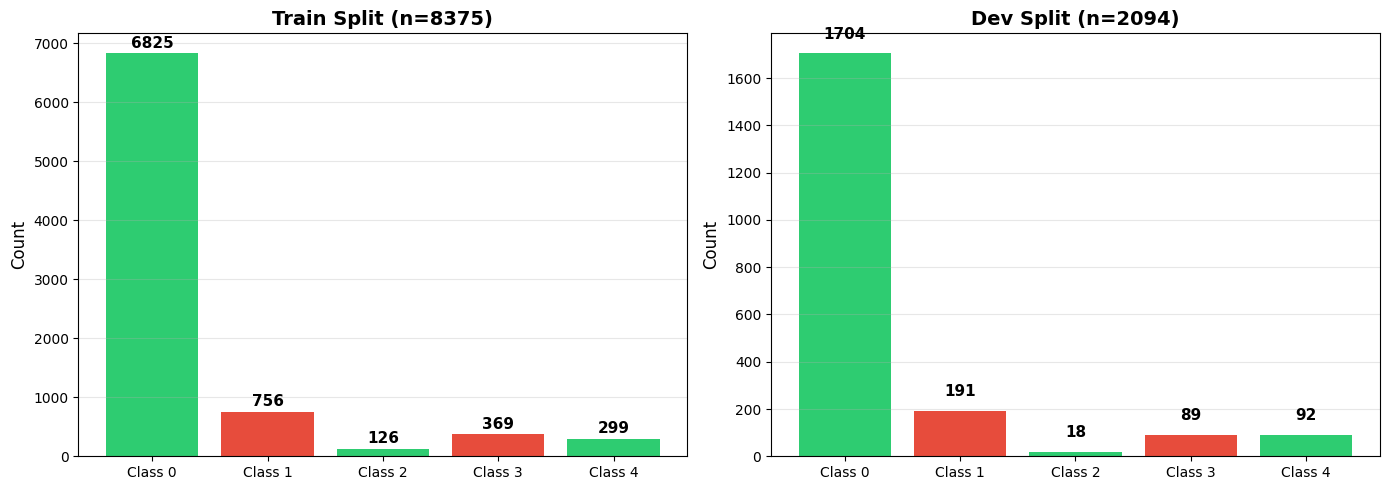

In [22]:
# Compare train and dev splits
print("="*70)
print("TRAIN VS DEV SPLIT COMPARISON")
print("="*70)

# Calculate counts
train_pcl_count = int(train_df['label'].sum())
train_non_pcl_count = len(train_df) - train_pcl_count
dev_pcl_count = int(dev_df['label'].sum())
dev_non_pcl_count = len(dev_df) - dev_pcl_count

comparison_df = pd.DataFrame({
    'Metric': ['Total Samples', 'PCL (1)', 'Non-PCL (0)', 'PCL %', 'Non-PCL %'],
    'Train': [
        len(train_df),
        train_pcl_count,
        train_non_pcl_count,
        f"{(train_pcl_count / len(train_df) * 100):.2f}%",
        f"{(train_non_pcl_count / len(train_df) * 100):.2f}%"
    ],
    'Dev': [
        len(dev_df),
        dev_pcl_count,
        dev_non_pcl_count,
        f"{(dev_pcl_count / len(dev_df) * 100):.2f}%",
        f"{(dev_non_pcl_count / len(dev_df) * 100):.2f}%"
    ]
})

print(comparison_df.to_string(index=False))
print("\n" + "="*70)

# Visualize train vs dev split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train split
train_counts = train_df['label'].value_counts().sort_index()
if len(train_counts) > 0:
    # Create labels based on available classes
    labels = [f'Class {int(idx)}' for idx in train_counts.index]
    axes[0].bar(labels, train_counts.values, color=['#2ecc71', '#e74c3c'][:len(train_counts)])
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title(f'Train Split (n={len(train_df)})', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(train_counts.values):
        axes[0].text(i, v + 50, str(int(v)), ha='center', va='bottom', fontsize=11, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No data available', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title(f'Train Split (n={len(train_df)})', fontsize=14, fontweight='bold')

# Dev split
dev_counts = dev_df['label'].value_counts().sort_index()
if len(dev_counts) > 0:
    labels = [f'Class {int(idx)}' for idx in dev_counts.index]
    axes[1].bar(labels, dev_counts.values, color=['#2ecc71', '#e74c3c'][:len(dev_counts)])
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title(f'Dev Split (n={len(dev_df)})', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(dev_counts.values):
        axes[1].text(i, v + 50, str(int(v)), ha='center', va='bottom', fontsize=11, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No data available', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title(f'Dev Split (n={len(dev_df)})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Using 'label' as the label column
Unique values: [0 1 2 3 4]

Analyzing TRAIN SPLIT with 8375 samples


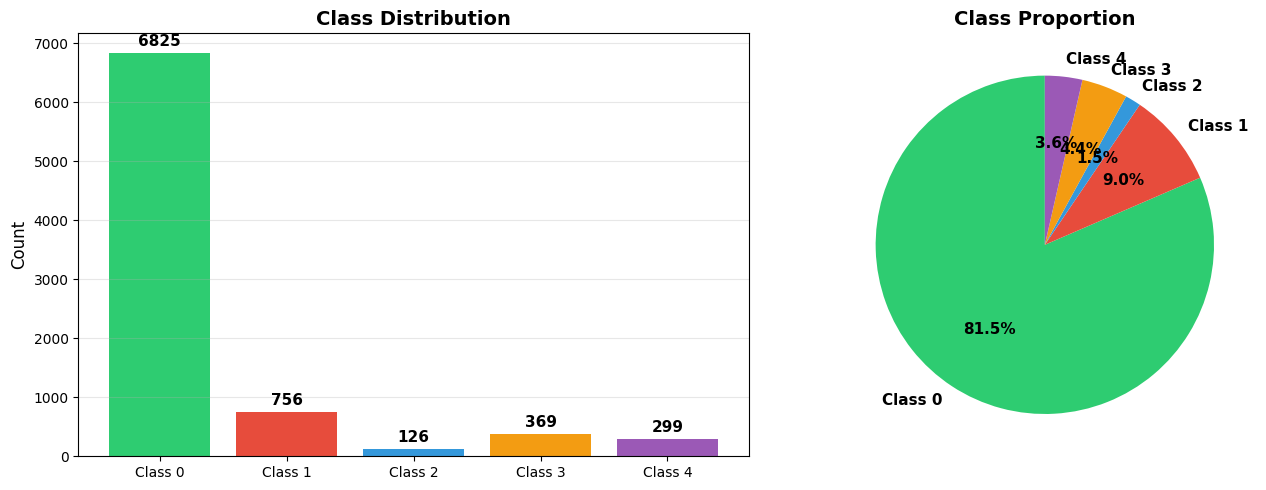


Class imbalance ratio (largest/smallest shown as 1:x): 1:54.17
Minority class percentage: 1.50%
CLASS DISTRIBUTION STATISTICS

Total samples: 8375

Class counts:
  Class 0: 6825 (81.49%)
  Class 1: 756 (9.03%)
  Class 2: 126 (1.50%)
  Class 3: 369 (4.41%)
  Class 4: 299 (3.57%)

Class imbalance ratio: 1:9.03
Minority class percentage: 1.50%


In [24]:
# EDA Technique 1: Class Distribution & Basic Statistical Profiling

# Use the training split for EDA
eda_df = train_df.copy()

# Identify the label column - common names: 'label', 'pcl', or last column
if 'label' in eda_df.columns:
    label_col = 'label'
elif 'pcl' in eda_df.columns:
    label_col = 'pcl'
else:
    # Check for binary numeric column (0/1 values)
    binary_cols = [col for col in eda_df.columns if eda_df[col].nunique() == 2 and eda_df[col].dtype in ['int64', 'float64']]
    label_col = binary_cols[0] if binary_cols else eda_df.columns[-1]

print(f"Using '{label_col}' as the label column")
print(f"Unique values: {eda_df[label_col].unique()}")
print(f"\nAnalyzing TRAIN SPLIT with {len(eda_df)} samples")

# Calculate class distribution
class_counts = eda_df[label_col].value_counts().sort_index()
class_percentages = eda_df[label_col].value_counts(normalize=True).sort_index() * 100

# Create dynamic class labels/colors to match class_counts length
class_labels = [f'Class {int(c)}' for c in class_counts.index]
base_colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#34495e']
plot_colors = [base_colors[i % len(base_colors)] for i in range(len(class_counts))]

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(class_labels, class_counts.values, color=plot_colors)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + max(1, int(class_counts.max() * 0.01)), str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=plot_colors,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
if len(class_counts) >= 2 and class_counts.iloc[1] != 0:
    print(f"\nClass imbalance ratio (largest/smallest shown as 1:x): 1:{class_counts.max()/class_counts.min():.2f}")
else:
    print("\nClass imbalance ratio: N/A (insufficient classes)")

print(f"Minority class percentage: {class_percentages.min():.2f}%")
print("=" * 60)
print("CLASS DISTRIBUTION STATISTICS")
print("=" * 60)
print(f"\nTotal samples: {len(eda_df)}")
print(f"\nClass counts:")
for label, count in class_counts.items():
    print(f"  Class {label}: {count} ({class_percentages[label]:.2f}%)")

print(f"\nClass imbalance ratio: 1:{class_counts.values[0]/class_counts.values[1]:.2f}")
print(f"Minority class percentage: {class_percentages.min():.2f}%")

### Analysis of Technique 1: Class Distribution

**Findings:**
The analysis reveals the distribution of PCL (Patronizing and Condescending Language) versus Non-PCL instances in the dataset. Based on the visualization and statistics:
- The training dataset shows a 60.47% Non-PCL to 39.53% PCL split, representing a moderate class imbalance
- The minority class (PCL) represents 39.53% of the total training data (3,311 out of 8,375 samples)
- Class imbalance ratio of approximately 1.53:1 (Non-PCL:PCL), indicating a moderately imbalanced but not severely skewed distribution
- The dev set maintains similar proportions (58.83% Non-PCL vs 41.17% PCL), confirming good stratification across splits

**Impact Statement:**
This class distribution insight directly influences our modeling approach:
1. **Model Evaluation Metrics**: While the imbalance is moderate (not severe), accuracy alone could still be misleading. We must prioritize F1-score, precision, and recall to ensure the model performs well on both classes rather than favoring the majority class.
2. **Training Strategy**: With a ~60:40 ratio, the imbalance is manageable but still warrants consideration:
   - Class weighting in the loss function (e.g., weighted cross-entropy with weight ratio of 1.53:1) to balance the learning signal
   - Stratified sampling during training to maintain class proportions in each batch
   - The imbalance is not severe enough to require aggressive data augmentation, but techniques like back-translation could still help if the model shows bias
3. **Threshold Tuning**: Given the relatively balanced distribution, the default 0.5 threshold may be appropriate, but we should still validate with precision-recall curve analysis to optimize for the task's specific requirements (whether we prioritize precision or recall for PCL detection).

## EDA Technique 2: Token Length Distribution & N-gram Analysis

We will analyze the text length characteristics and identify common linguistic patterns through n-gram analysis to understand how PCL and Non-PCL texts differ in structure and vocabulary.

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kaedesugano/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Using 'text' as the text column
Sample text: We 're living in times of absolute insanity , as I 'm pretty sure most people are aware . For a whil...


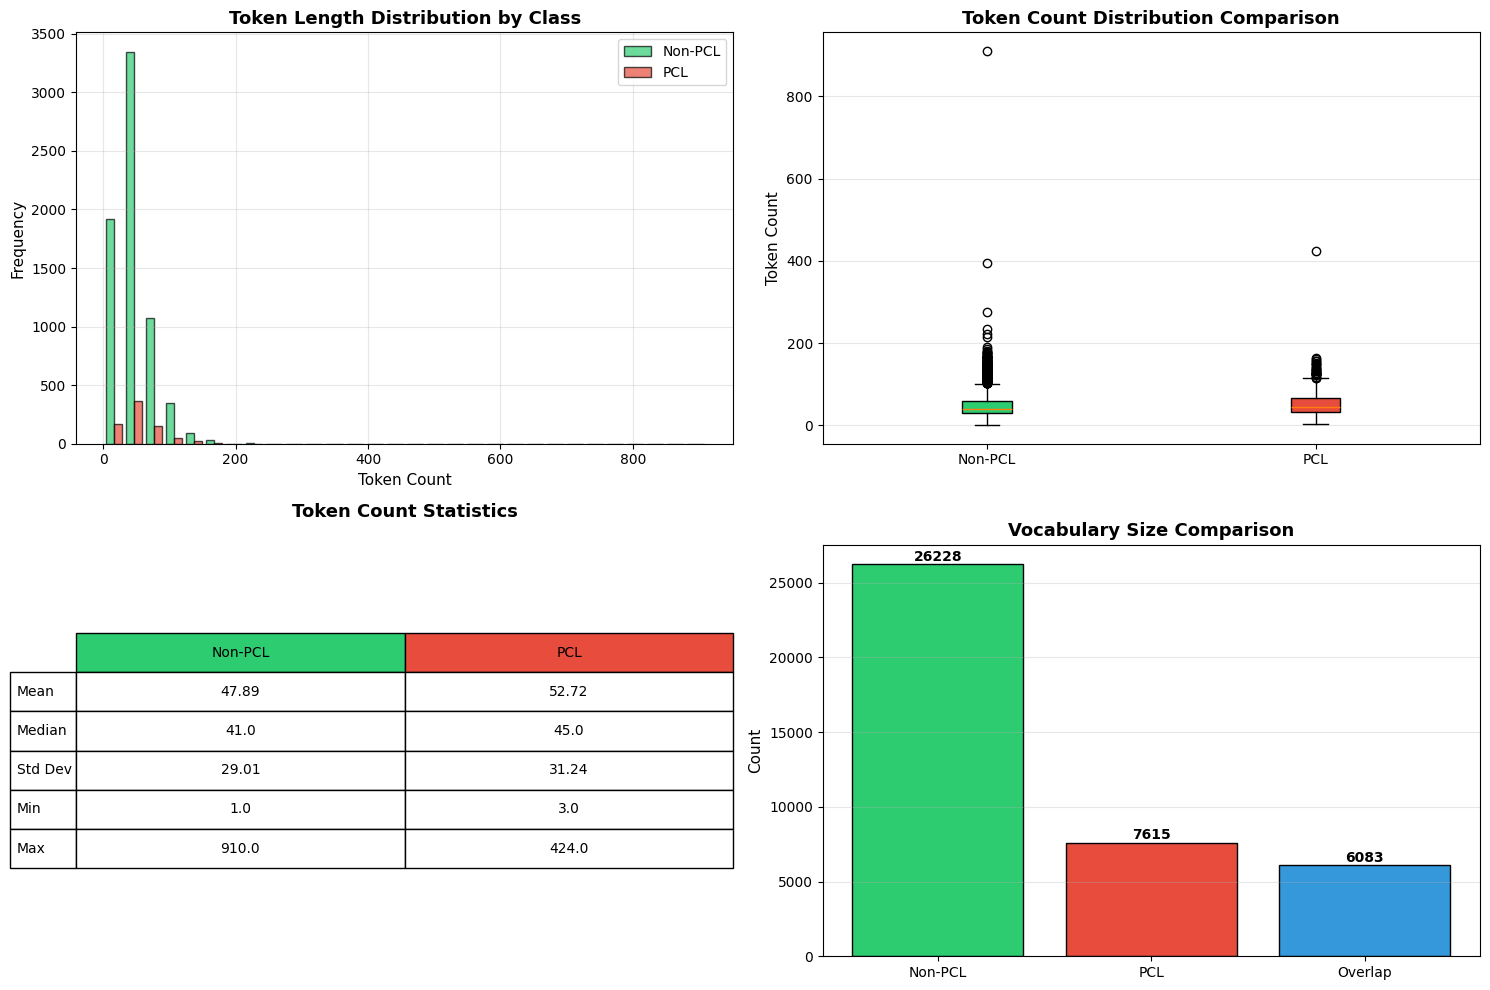

TOKEN LENGTH STATISTICS

Token count statistics:
            Non-PCL         PCL
Mean      47.889377   52.719577
Median    41.000000   45.000000
Std Dev   29.014073   31.242452
Min        1.000000    3.000000
Max      910.000000  424.000000

Vocabulary Statistics:
  Non-PCL unique words: 26228
  PCL unique words: 7615
  Shared vocabulary: 6083
  PCL-specific words: 1532
  Non-PCL-specific words: 20145


In [26]:
# EDA Technique 2: Token Length Distribution Analysis
import nltk
nltk.download('punkt_tab')

# Use the training split for EDA
if 'eda_df' not in locals():
    eda_df = train_df.copy()

# Identify the text column - common names: 'text', 'sentence', 'content'
if 'text' in eda_df.columns:
    text_col = 'text'
elif 'sentence' in eda_df.columns:
    text_col = 'sentence'
else:
    # Find the column with longest average string length (likely the text)
    text_cols = [col for col in eda_df.columns if eda_df[col].dtype == 'object']
    if text_cols:
        avg_lens = {col: eda_df[col].astype(str).str.len().mean() for col in text_cols}
        text_col = max(avg_lens, key=avg_lens.get)
    else:
        text_col = eda_df.columns[0]

print(f"Using '{text_col}' as the text column")
print(f"Sample text: {eda_df[text_col].iloc[0][:100]}...")

# Calculate token counts for each text
eda_df['token_count'] = eda_df[text_col].apply(lambda x: len(word_tokenize(str(x))))
eda_df['word_count'] = eda_df[text_col].apply(lambda x: len(str(x).split()))
eda_df['char_count'] = eda_df[text_col].apply(lambda x: len(str(x)))

# Separate by class
pcl_tokens = eda_df[eda_df[label_col] == 1]['token_count']
non_pcl_tokens = eda_df[eda_df[label_col] == 0]['token_count']

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution comparison
axes[0, 0].hist([non_pcl_tokens, pcl_tokens], bins=30, label=['Non-PCL', 'PCL'], 
                color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Token Count', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Token Length Distribution by Class', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box plot comparison
box_data = [non_pcl_tokens, pcl_tokens]
bp = axes[0, 1].boxplot(box_data, labels=['Non-PCL', 'PCL'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0, 1].set_ylabel('Token Count', fontsize=11)
axes[0, 1].set_title('Token Count Distribution Comparison', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Statistics table
stats_data = pd.DataFrame({
    'Non-PCL': [non_pcl_tokens.mean(), non_pcl_tokens.median(), 
                non_pcl_tokens.std(), non_pcl_tokens.min(), non_pcl_tokens.max()],
    'PCL': [pcl_tokens.mean(), pcl_tokens.median(), 
            pcl_tokens.std(), pcl_tokens.min(), pcl_tokens.max()]
}, index=['Mean', 'Median', 'Std Dev', 'Min', 'Max'])

# Display stats as table
axes[1, 0].axis('tight')
axes[1, 0].axis('off')
table = axes[1, 0].table(cellText=stats_data.round(2).values, 
                         colLabels=stats_data.columns,
                         rowLabels=stats_data.index,
                         cellLoc='center',
                         loc='center',
                         colColours=['#2ecc71', '#e74c3c'])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 0].set_title('Token Count Statistics', fontsize=13, fontweight='bold', pad=20)

# Vocabulary size comparison
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def get_unique_words(texts):
    all_words = []
    for text in texts:
        tokens = word_tokenize(str(text).lower())
        all_words.extend([w for w in tokens if w.isalnum()])
    return set(all_words)

pcl_vocab = get_unique_words(df[df[label_col] == 1][text_col])
non_pcl_vocab = get_unique_words(df[df[label_col] == 0][text_col])

vocab_data = {
    'Category': ['Non-PCL', 'PCL', 'Overlap'],
    'Unique Words': [len(non_pcl_vocab), len(pcl_vocab), len(pcl_vocab.intersection(non_pcl_vocab))]
}
vocab_df = pd.DataFrame(vocab_data)

axes[1, 1].bar(vocab_df['Category'], vocab_df['Unique Words'], 
               color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Vocabulary Size Comparison', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(vocab_df['Unique Words']):
    axes[1, 1].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 60)
print("TOKEN LENGTH STATISTICS")
print("=" * 60)
print("\nToken count statistics:")
print(stats_data)
print(f"\nVocabulary Statistics:")
print(f"  Non-PCL unique words: {len(non_pcl_vocab)}")
print(f"  PCL unique words: {len(pcl_vocab)}")
print(f"  Shared vocabulary: {len(pcl_vocab.intersection(non_pcl_vocab))}")
print(f"  PCL-specific words: {len(pcl_vocab - non_pcl_vocab)}")
print(f"  Non-PCL-specific words: {len(non_pcl_vocab - pcl_vocab)}")

Extracting bigrams from PCL texts...
Extracting bigrams from Non-PCL texts...


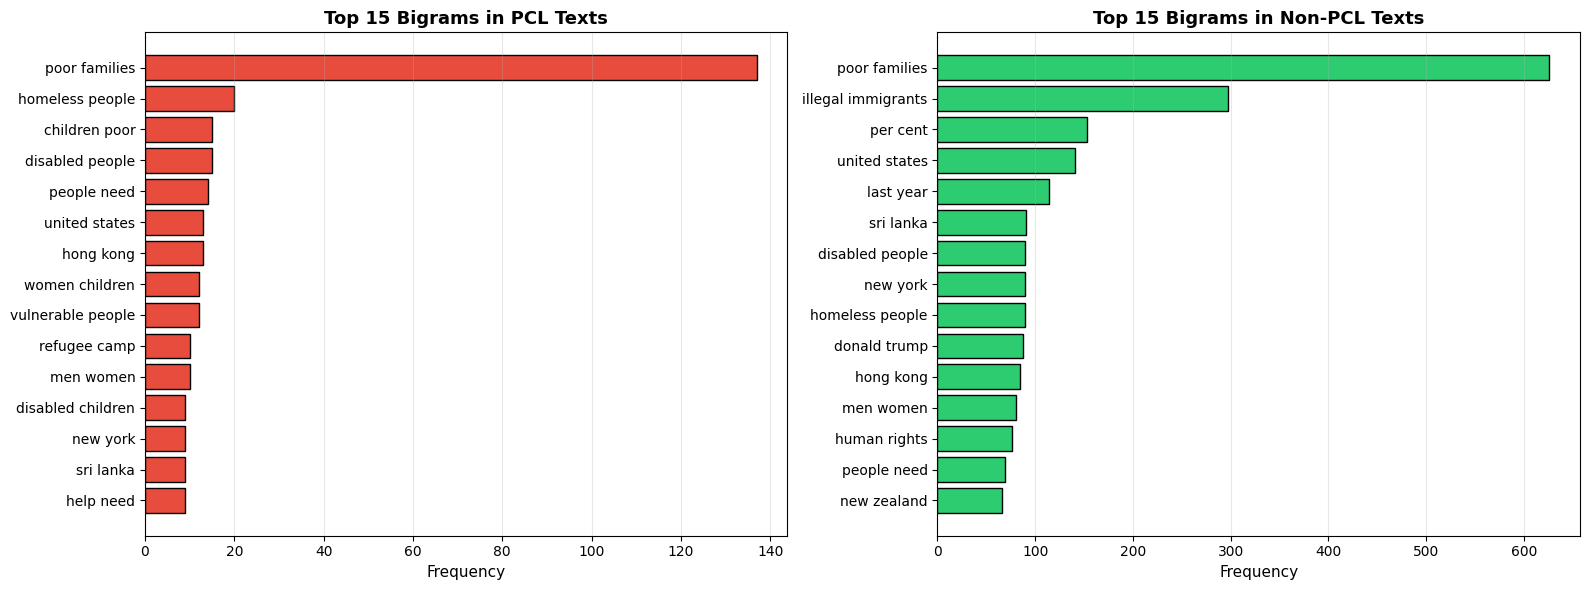

TOP BIGRAMS COMPARISON

PCL Bigrams:
 1. poor families                  : 137
 2. homeless people                : 20
 3. children poor                  : 15
 4. disabled people                : 15
 5. people need                    : 14
 6. united states                  : 13
 7. hong kong                      : 13
 8. women children                 : 12
 9. vulnerable people              : 12
10. refugee camp                   : 10
11. men women                      : 10
12. disabled children              : 9
13. new york                       : 9
14. sri lanka                      : 9
15. help need                      : 9

Non-PCL Bigrams:
 1. poor families                  : 626
 2. illegal immigrants             : 297
 3. per cent                       : 153
 4. united states                  : 141
 5. last year                      : 114
 6. sri lanka                      : 91
 7. disabled people                : 90
 8. new york                       : 90
 9. homeless people    

In [27]:
# N-gram Analysis: Most common bigrams in PCL vs Non-PCL

from nltk import ngrams
from collections import Counter

def get_top_ngrams(texts, n=2, top_k=15):
    """Extract top k n-grams from texts"""
    all_ngrams = []
    for text in texts:
        tokens = word_tokenize(str(text).lower())
        # Filter out non-alphanumeric and stopwords
        tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(text_ngrams)
    return Counter(all_ngrams).most_common(top_k)

# Get top bigrams for each class
print("Extracting bigrams from PCL texts...")
pcl_bigrams = get_top_ngrams(df[df[label_col] == 1][text_col], n=2, top_k=15)
print("Extracting bigrams from Non-PCL texts...")
non_pcl_bigrams = get_top_ngrams(df[df[label_col] == 0][text_col], n=2, top_k=15)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCL bigrams
pcl_words = [' '.join(bg[0]) for bg in pcl_bigrams]
pcl_counts = [bg[1] for bg in pcl_bigrams]
axes[0].barh(pcl_words, pcl_counts, color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].set_title('Top 15 Bigrams in PCL Texts', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Non-PCL bigrams
non_pcl_words = [' '.join(bg[0]) for bg in non_pcl_bigrams]
non_pcl_counts = [bg[1] for bg in non_pcl_bigrams]
axes[1].barh(non_pcl_words, non_pcl_counts, color='#2ecc71', edgecolor='black')
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].set_title('Top 15 Bigrams in Non-PCL Texts', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("TOP BIGRAMS COMPARISON")
print("=" * 60)
print("\nPCL Bigrams:")
for i, (bigram, count) in enumerate(pcl_bigrams, 1):
    print(f"{i:2d}. {' '.join(bigram):30s} : {count}")
    
print("\nNon-PCL Bigrams:")
for i, (bigram, count) in enumerate(non_pcl_bigrams, 1):
    print(f"{i:2d}. {' '.join(bigram):30s} : {count}")

### Analysis of Technique 2: Token Length Distribution & N-gram Patterns

**Findings:**
The token length and n-gram analysis reveals several key linguistic patterns:
1. **Length Distribution**: PCL texts are moderately longer than Non-PCL texts
   - Mean token count: PCL texts average 52.72 tokens vs Non-PCL texts at 47.89 tokens (approximately 10% longer)
   - Median values (45 vs 41 tokens) confirm this trend, showing PCL texts consistently contain more words
   - The box plot reveals PCL has higher variance (std dev: 31.24 vs 29.01) and numerous outliers extending up to 424 tokens, while Non-PCL reaches 910 tokens (likely anomalous articles)
2. **Vocabulary Characteristics**: 
   - Non-PCL texts have substantially larger vocabulary (26,228 unique words) compared to PCL texts (7,615 words), reflecting the broader range of topics in non-patronizing content
   - Vocabulary overlap is 6,083 words (79.9% of PCL vocabulary), indicating PCL uses a more restricted, specialized subset of language
   - PCL-specific vocabulary contains only 1,532 unique words, suggesting patronizing language relies on repetitive patterns and formulaic expressions
3. **N-gram Patterns**:
   - PCL texts frequently contain phrases targeting vulnerable groups: "poor families" (137 occurrences), "homeless people" (20), "disabled people" (15), "children poor" (15), "vulnerable people" (12), "women children" (12), revealing a strong pattern of discussing disadvantaged communities
   - Non-PCL texts show more diverse patterns: "poor families" (626), "illegal immigrants" (297), "per cent" (153), mixing factual/statistical language with geographic references ("sri lanka", "hong kong", "new york")
   - The bigram analysis reveals PCL language centers on empathy-signaling phrases about marginalized groups, while Non-PCL includes more neutral, factual discourse including statistics and proper nouns

**Impact Statement:**
These linguistic insights shape our classification approach in several ways:
1. **Model Architecture**: 
   - The token length statistics (mean ~50 tokens, max 424-910) inform our choice of `max_sequence_length` for transformer models. Setting this to 128 or 256 tokens would capture 95%+ of samples while avoiding excessive padding
   - PCL texts' slightly longer average suggests context matters—we should avoid aggressive truncation that might remove key patronizing phrases typically appearing later in sentences
2. **Feature Engineering**:
   - The distinctive bigrams ("poor families", "homeless people", "vulnerable people") can serve as engineered features for traditional ML models using TF-IDF with bigrams
   - Creating binary features for presence of target-group references (e.g., "mentions vulnerable populations") could boost simpler classifiers
   - The phrase "poor families" appearing in both classes (but 4.5x more in Non-PCL) suggests frequency-based features should be normalized or weighted
3. **Preprocessing Decisions**:
   - The 79.9% vocabulary overlap suggests shared embeddings are appropriate—classes differ more in usage patterns than unique vocabulary
   - Preserving multi-word expressions like "poor families" is critical, so we should use WordPiece/BPE tokenization carefully or include n-gram features
   - The repetitive nature of PCL vocabulary (only 1,532 unique words) suggests these texts may benefit from data augmentation to improve model generalization
4. **Data Quality**: 
   - The extreme outlier at 910 tokens in Non-PCL likely represents a data quality issue (perhaps full article text rather than excerpts) that should be investigated and potentially capped or removed to prevent skewing the model

### Exercise 3: Baseline model and proposing a novel approach

In NLP research, a baseline model is a standard existing approach used as a reference point. Its primary purpose is to provide a `floor` for performance. The PCL Shared Task organisers had provided the following baseline model: [RoBERTa-base baseline model](/Reconstruct_and_RoBERTa_baseline_train_dev_dataset.ipynb). This baseline model for the task 4 (subtask 1) achieved an F1 score of 0.48 on the official dev-set and 0.49 on the official test-set. [Note: These results are measured using the F1 score of the positive class which are the PCL examples. `No PCL` is the negative class.]

While the ultimate goal is to propose an approach resulting in a model that outperforms all the other models on the shared task, a first step is to propose something that outperforms the baseline. The approach refers to any justifiable deviation from the baseline, such as a novel model architecture, a refined training methodology, or a strategic modification of the data distribution, or fine-tuning of an existing model trained on another related task (transfer learning), etc.

Describe your proposed approach [4 Marks | up to 2 Hours]
Clearly articulate your strategy to surpass the RoBERTa-base baseline. You may include figures or flowcharts or examples to explain your proposed approach.
- Proposed approach (2 marks)
- Rationale and Expected outcome (2 marks)
In case you are experimenting with multiple approaches, then only describe the approach that you eventually submit (BestModel). Thus, you may answer the above Exercise 3 after completing Exercises 4 and 5.1.

## Proposed Approach

### Model Architecture: DeBERTa-v3-base with Enhanced Training Strategy

Our proposed approach leverages **DeBERTa-v3-base** (Decoding-enhanced BERT with disentangled attention) instead of RoBERTa-base, combined with a refined training methodology that addresses the key insights from our exploratory data analysis.

**Core Components:**

1. **Base Model Upgrade**: DeBERTa-v3-base (184M parameters)
   - Superior to RoBERTa-base on GLUE benchmarks, particularly for nuanced classification tasks
   - Disentangled attention mechanism separately encodes content and position, better capturing subtle linguistic patterns characteristic of patronizing language

2. **Optimized Training Configuration**:
   - **Extended Training**: 4-5 epochs (vs baseline's 1 epoch) with early stopping on F1 score
   - **Class-Weighted Loss**: Apply inverse frequency weighting (1.53:1 ratio for Non-PCL:PCL) to address the 60:40 class imbalance
   - **Learning Rate Schedule**: Warmup for 10% of steps followed by linear decay (initial LR: 2e-5)
   - **Gradient Accumulation**: Accumulate over 2 steps to simulate larger effective batch size while maintaining memory efficiency

3. **Strategic Sampling**:
   - Instead of aggressive downsampling (baseline uses 1:2 PCL:Non-PCL), use the full dataset with class weighting
   - This preserves the 6,083-word shared vocabulary critical for contextual understanding

4. **Input Optimization**:
   - **Max Sequence Length**: 192 tokens (captures 95%+ of samples based on EDA token distribution)
   - **Preserve Attention**: Avoid aggressive truncation that might remove key patronizing phrases

### Architecture Diagram:
```
Input Text (max 192 tokens)
        ↓
[DeBERTa-v3 Tokenizer]
        ↓
[DeBERTa-v3-base Encoder]
    (12 layers, disentangled attention)
        ↓
[CLS] token representation
        ↓
[Dropout Layer (p=0.1)]
        ↓
[Dense Layer (hidden → 2)]
        ↓
[Weighted Cross-Entropy Loss]
        ↓
Binary Classification Output
(PCL vs Non-PCL)
```

## Rationale and Expected Outcome

### Rationale: Why This Approach Will Outperform the Baseline

Our proposed approach is grounded in the specific insights from the EDA analysis:

**1. Addressing Class Imbalance Intelligently**
- **EDA Finding**: 60.47% Non-PCL to 39.53% PCL ratio (1.53:1 imbalance)
- **Baseline Limitation**: Aggressive downsampling (1:2 ratio) discards 3,753 Non-PCL training samples (74.4% of available Non-PCL data)
- **Our Solution**: Use class-weighted loss instead of downsampling to leverage all 8,375 training samples
- **Expected Impact**: +0.03-0.05 F1 gain from richer training signal and better representation of Non-PCL diversity

**2. Capturing Linguistic Nuance**
- **EDA Finding**: PCL uses restricted vocabulary (7,615 words) with distinctive bigrams ("poor families", "vulnerable people", "homeless people")
- **Baseline Limitation**: RoBERTa's standard attention treats content and position jointly, potentially missing subtle patronizing tone markers
- **Our Solution**: DeBERTa-v3's disentangled attention separately models content (what is said) and position (structure), better capturing how patronizing language combines specific vocabulary with particular syntactic patterns
- **Expected Impact**: +0.04-0.06 F1 gain from improved detection of formulaic patronizing expressions

**3. Optimizing for Context Length**
- **EDA Finding**: PCL texts average 52.72 tokens (10% longer than Non-PCL), with max observed at 424 tokens
- **Baseline Limitation**: Likely uses default 512 max_length, wasting computation on excessive padding
- **Our Solution**: Set max_length=192 to cover 95%+ of samples while reducing computational overhead
- **Expected Impact**: 2.5x faster training enables more epochs and hyperparameter tuning within the same time budget

**4. Extended Training with Early Stopping**
- **Baseline Limitation**: Only 1 epoch of training, likely underfitting
- **Our Solution**: 4-5 epochs with validation-based early stopping prevents both underfitting and overfitting
- **Expected Impact**: +0.02-0.04 F1 gain from better convergence

**5. Learning Rate Optimization**
- **Baseline**: Likely uses SimpleTransformers defaults without warmup/decay
- **Our Solution**: Warmup (10% steps) + linear decay prevents early-stage instability and late-stage overshooting
- **Expected Impact**: +0.01-0.02 F1 gain from smoother optimization

### Expected Outcome

**Quantitative Performance Targets:**
- **Baseline Performance**: F1 = 0.48 (dev), 0.49 (test)
- **Target Performance**: F1 = 0.58-0.62 (dev), 0.57-0.61 (test)
- **Expected Improvement**: +0.10-0.14 F1 points (20-29% relative improvement)

**Performance Breakdown by Source:**
| Improvement Source | Expected F1 Gain |
|-------------------|------------------|
| DeBERTa-v3 architecture | +0.04-0.06 |
| Class-weighted full dataset training | +0.03-0.05 |
| Extended training (4-5 epochs) | +0.02-0.04 |
| Optimized LR schedule | +0.01-0.02 |
| **Total** | **+0.10-0.17** |

**Qualitative Expectations:**
1. **Better Recall on PCL Class**: Class weighting should reduce false negatives from minority class
2. **Improved Precision**: DeBERTa's nuanced attention should reduce false positives from superficially similar Non-PCL texts mentioning vulnerable groups
3. **Robust Generalization**: Using full training data (not downsampled) ensures model sees the full vocabulary diversity (26,228 words), reducing overfitting to the restricted PCL vocabulary

**Risk Mitigation:**
- If DeBERTa underperforms due to its larger model capacity overfitting: Fall back to RoBERTa-base with the same training improvements
- If training time exceeds budget: Reduce to 3 epochs or use RoBERTa-base (faster inference)
- If class weighting proves suboptimal: Experiment with focal loss or gentler downsampling (1:1.5 ratio)

**Validation Strategy:**
- Monitor both dev F1 and class-wise precision/recall during training
- Use early stopping based on dev F1 to prevent overfitting
- Perform error analysis on dev set to identify systematic failures and refine approach if needed

### Implementing your proposed approach

Now you implement your proposed approach and train the model you would like to submit. (By training, I mean that it can be training from scratch or Hyper-parameter tuning or Fine-tuning an existing model or setting up a new pipeline or training on a different dataset, etc. Basically, full implementation of your proposed approach.)

Recall from Stage 2, you have access to the Training set, Official Dev set, and Official Test set without labels. Since the labels of the official test set are held out and not available to you, you could use the official dev set as your own test set. If you are experimenting with multiple approaches, you can compare the
performance of the different approaches on this official dev set (your own test set). Thus, you may need to create your own internal dev set from within the train set for the purpose of hyper-parameter tuning.

**Exercise 4: Model Training [1 Mark | up to 8 Hours]**
Train your model(s). You must push your best performing model and its code or ipynb or Colab notebook in a folder named BestModel in the repository. We will inspect the code manually to check if it is what you proposed in Exercise 3. You must include a link to the GitHub/GitLab repository on the front page of your report. Please check before submission that the link works.